In [1]:
import pandas as pd
import numpy as np
import os
## For ml-lab-serveer1
ROOT_FOLDER = ROOT_FOLDER = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..')) + os.sep
print(ROOT_FOLDER)
GRAPH_BUILDING_DIR = os.path.join(ROOT_FOLDER, "NGAT", "code", "graph_building")

c:\Users\quinb\Desktop\UW CFRM\522\Research Paper 1\522 Replication Code\


### Define Positive/Negative confusion matrix function

In [2]:
def pn_confusion_matrix(output_folder, dataset_name, label="rmean5"):
    """
    Calculate the Positive/Negative -- Increase/Decrease confusion matrix
    """
    model = output_folder.split("\\")[-2]
    
    last_status = pd.read_csv(output_folder+dataset_name+"_last.csv")
    pred= pd.read_csv(output_folder+dataset_name+"_pred.csv")
    true = pd.read_csv(output_folder+dataset_name+"_true.csv")

    df = pd.concat([
        pred[label+'_'+dataset_name+'_pred'],
        true[label+'_'+dataset_name+'_true'],
        last_status[label+'_'+dataset_name+'_last'],
        ], axis=1)
    df.columns = ['pred', 'true', 'last']

    # denominator: Number of rows where "last"=0 and "true"=1
    denominator = len(df[(df['last'] == 0) & (df['true'] == 1)])
    # numerator: Number of rows where "last"=0, "true"=1, and "pred">0.5
    numerator = len(df[(df['last'] == 0) & (df['true'] == 1) & (df['pred'] > 0.5)])
    # last negative next increase accuracy
    ln_ni = numerator/ denominator
    print("LN_N+: ", numerator, denominator)
    
    # denominator: Number of rows where "last"=0 and "true"=0
    denominator = len(df[(df['last'] == 0) & (df['true'] == 0)])
    # numerator: Number of rows where "last"=0, "true"=0, and "pred"<0.5
    numerator = len(df[(df['last'] == 0) & (df['true'] == 0) & (df['pred'] < 0.5)])
    # last negative next decrease accuracy
    ln_nd = numerator/ denominator
    print("LN_N-: ", numerator, denominator)

    # denominator: Number of rows where "last"=1 and "true"=1
    denominator = len(df[(df['last'] == 1) & (df['true'] == 1)])
    # numerator: Number of rows where "last"=1, "true"=1, and "pred">0.5
    numerator = len(df[(df['last'] == 1) & (df['true'] == 1) & (df['pred'] > 0.5)])
    # last negative next increase accuracy
    lp_ni = numerator/ denominator
    print("LP_N+: ", numerator, denominator)

    # denominator: Number of rows where "last"=1 and "true"=0
    denominator = len(df[(df['last'] == 1) & (df['true'] == 0)])
    # numerator: Number of rows where "last"=1, "true"=0, and "pred"<0.5
    numerator = len(df[(df['last'] == 1) & (df['true'] == 0) & (df['pred'] < 0.5)])
    # last negative next decrease accuracy
    lp_nd = numerator/ denominator
    print("LP_N-: ", numerator, denominator)

    print("Dataset: ", dataset_name, " Model: ", model)
    print("LN_N+ : ", ln_ni, " LP_N+: ", lp_ni)
    print("LN_N- : ", ln_nd, " LP_N-: ", lp_nd)

    return df

## ACL2018 Dataset

### LSTM model prediction output review

In [ ]:
output_folder = os.path.join(ROOT_FOLDER, "NGAT", "code", "notebook", "lstm") + os.sep
dataset_name = "ACL2018"

df = pn_confusion_matrix(output_folder=output_folder, dataset_name=dataset_name, label="rmean5")

LN_N+:  611 801
LN_N-:  764 1039
LP_N+:  719 893
LP_N-:  735 1067
Dataset:  ACL2018  Model:  lstm
LN_N+ :  0.762796504369538  LP_N+:  0.8051511758118701
LN_N- :  0.7353224254090471  LP_N-:  0.6888472352389878


In [ ]:
df

,pred,true,last
0,0.341698,0.0,1.0
1,0.479939,1.0,0.0
2,0.611213,1.0,1.0
3,0.742993,1.0,0.0
4,0.212359,0.0,0.0
...,...,...,...
3795,0.381150,0.0,1.0
3796,0.546671,0.0,0.0
3797,0.766435,0.0,1.0
3798,0.457144,1.0,1.0


In [5]:
df = pn_confusion_matrix(output_folder=output_folder, dataset_name=dataset_name, label="rmean10")

LN_N+:  487 630
LN_N-:  724 996
LP_N+:  734 911
LP_N-:  851 1263
Dataset:  ACL2018  Model:  lstm
LN_N+ :  0.773015873015873  LP_N+:  0.8057080131723381
LN_N- :  0.7269076305220884  LP_N-:  0.6737925574030087


In [6]:
df = pn_confusion_matrix(output_folder=output_folder, dataset_name=dataset_name, label="rmean21")

LN_N+:  369 467
LN_N-:  713 1027
LP_N+:  495 633
LP_N-:  1069 1673
Dataset:  ACL2018  Model:  lstm
LN_N+ :  0.7901498929336188  LP_N+:  0.7819905213270142
LN_N- :  0.6942551119766309  LP_N-:  0.6389719067543336


### NGAT model prediction output review

In [7]:
output_folder = os.path.join(ROOT_FOLDER, "NGAT", "code", "notebook", "ngat") + os.sep
dataset_name = "ACL2018"

df = pn_confusion_matrix(output_folder=output_folder, dataset_name=dataset_name, label="rmean5")

LN_N+:  622 801
LN_N-:  831 1039
LP_N+:  731 893
LP_N-:  770 1067
Dataset:  ACL2018  Model:  ngat
LN_N+ :  0.7765293383270911  LP_N+:  0.8185890257558791
LN_N- :  0.7998075072184793  LP_N-:  0.7216494845360825


In [8]:
df

,pred,true,last
0,0.345610,0.0,1.0
1,0.591588,1.0,0.0
2,0.464041,1.0,1.0
3,0.757062,1.0,0.0
4,0.153381,0.0,0.0
...,...,...,...
3795,0.439401,0.0,1.0
3796,0.536941,0.0,0.0
3797,0.801366,0.0,1.0
3798,0.488728,1.0,1.0


In [9]:
df = pn_confusion_matrix(output_folder=output_folder, dataset_name=dataset_name, label="rmean10")

LN_N+:  465 630
LN_N-:  794 996
LP_N+:  750 911
LP_N-:  934 1263
Dataset:  ACL2018  Model:  ngat
LN_N+ :  0.7380952380952381  LP_N+:  0.823271130625686
LN_N- :  0.7971887550200804  LP_N-:  0.7395091053048297


In [10]:
df = pn_confusion_matrix(output_folder=output_folder, dataset_name=dataset_name, label="rmean21")

LN_N+:  355 467
LN_N-:  711 1027
LP_N+:  491 633
LP_N-:  1091 1673
Dataset:  ACL2018  Model:  ngat
LN_N+ :  0.7601713062098501  LP_N+:  0.7756714060031595
LN_N- :  0.6923076923076923  LP_N-:  0.6521219366407651


### NGAT model prediction output save file


In [4]:
import torch
import pandas as pd

def create_dataframe(index_path, pred_mean_path, pred_std_path, label_mean_path, label_std_path, valid_firms_path, dates_path, price_dir):
    # 加载数据
    index = torch.load(index_path)
    pred_mean = torch.load(pred_mean_path)
    pred_std = torch.load(pred_std_path)
    label_mean = torch.load(label_mean_path)
    label_std = torch.load(label_std_path)
    valid_firms = torch.load(valid_firms_path)
    dates = torch.load(dates_path)

    # 截取需要的日期
    truncated_dates = dates[index[0]:]
    if index.shape[0] != len(truncated_dates):
        # safer check: ensure lengths match expected days
        pass

    # names for possible channels (only the prefix list; we'll slice by actual tensor size)
    pred_mean_names = ['Rmean_1d', 'Rmean_5d', 'Rmean_10d', 'Rmean_21d']
    pred_std_names  = ['Volatility_5d', 'Volatility_10d', 'Volatility_21d']
    label_mean_names= ['Label_Rmean_1d', 'Label_Rmean_5d', 'Label_Rmean_10d', 'Label_Rmean_21d']
    label_std_names = ['Label_Volatility_5d', 'Label_Volatility_10d', 'Label_Volatility_21d']

    # cache price files to avoid repeated I/O
    price_cache = {firm: pd.read_csv(f"{price_dir}/{firm}.csv") for firm in valid_firms}

    data = []
    days = index.shape[0]

    for day in range(days):
        for firm_idx, firm in enumerate(valid_firms):
            date_str = truncated_dates[day]
            pf = price_cache[firm]
            mask = pf['Date'] == date_str
            close_price = pf.loc[mask, 'Close'].iloc[0] if mask.any() else None

            row = {
                'Date': date_str,
                'Ticker': firm,
                'Close_Price': close_price
            }

            # safely add pred_mean channels that exist
            for i in range(min(pred_mean.shape[2], len(pred_mean_names))):
                row[pred_mean_names[i]] = pred_mean[day, firm_idx, i].item()

            for i in range(min(pred_std.shape[2], len(pred_std_names))):
                row[pred_std_names[i]] = pred_std[day, firm_idx, i].item()

            for i in range(min(label_mean.shape[2], len(label_mean_names))):
                row[label_mean_names[i]] = label_mean[day, firm_idx, i].item()

            for i in range(min(label_std.shape[2], len(label_std_names))):
                row[label_std_names[i]] = label_std[day, firm_idx, i].item()

            data.append(row)

    df = pd.DataFrame(data)
    return df

# 使用示例
ROOT_FOLDER = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..')) + os.sep
index_path = os.path.join(ROOT_FOLDER, "NGAT", "code", "index_mean.pt")
pred_mean_path = os.path.join(ROOT_FOLDER, "NGAT", "code", "pred_mean.pt")
pred_std_path = os.path.join(ROOT_FOLDER, "NGAT", "code", "pred_std.pt")
label_mean_path = os.path.join(ROOT_FOLDER, "NGAT", "code", "label_mean.pt")
label_std_path = os.path.join(ROOT_FOLDER, "NGAT", "code", "label_std.pt")
valid_firms_path = os.path.join(ROOT_FOLDER, "NGAT", "code", "valid_firms.pt")
dates_path = "../valid_days.pt"

price_dir = os.path.join(ROOT_FOLDER, "NGAT", "data", "raw", "ACL2018", "price", "raw") #ACL2018 Or SPNews

df = create_dataframe(index_path, pred_mean_path, pred_std_path, label_mean_path, label_std_path, valid_firms_path, dates_path, price_dir)
df.head()

,Date,Ticker,Close_Price,Rmean_1d,Rmean_5d,Rmean_10d,Volatility_5d,Volatility_10d,Volatility_21d,Label_Rmean_1d,Label_Rmean_5d,Label_Rmean_10d,Label_Volatility_5d,Label_Volatility_10d,Label_Volatility_21d
0,2015-10-21,AAPL,113.760002,-0.194174,-0.226647,-0.209902,0.048639,-0.112191,0.094431,0.945976,0.699301,0.225969,2.931439,2.088739,1.963267
1,2015-10-21,ABBV,53.830002,-0.179948,-0.214748,-0.248460,0.050721,-0.096874,0.095822,-0.212908,1.699224,0.560184,6.097614,5.379972,3.893094
2,2015-10-21,AEP,58.939999,-0.200984,-0.234753,-0.195420,0.032976,-0.102147,0.091527,-0.644826,-0.385693,-0.169083,1.412339,1.141546,1.426069
3,2015-10-21,AMGN,150.089996,-0.196596,-0.222377,-0.250027,0.046375,-0.121243,0.108635,1.609771,0.756204,0.313310,0.726400,1.493263,1.579121
4,2015-10-21,AMZN,555.770020,-0.191907,-0.218292,-0.238016,0.038677,-0.110006,0.095948,2.093529,1.425969,0.827656,2.255984,1.848405,1.896398


In [5]:
df.to_excel("Prediction_ACL2018.xlsx")

In [13]:
import pandas as pd
import os
import torch

def create_price_dataframe(price_dir, valid_firms_path):
    """
    根据price_dir和valid_firms读取每一个ticker的所有close price数据，并将数据日期对齐后整合到一个DataFrame中。

    Args:
    price_dir (str): 存储价格文件的目录路径
    valid_firms (list): 存储公司ticker的列表

    Returns:
    pd.DataFrame: 整合后的DataFrame
    """
    valid_firms = torch.load(valid_firms_path)
    # 初始化一个空的DataFrame用于存储所有公司的close price数据
    all_prices_df = pd.DataFrame()

    for firm in valid_firms:
        # 读取每个公司的价格文件
        price_file_path = os.path.join(price_dir, f"{firm}.csv")
        price_df = pd.read_csv(price_file_path, usecols=['Date', 'Close'])
        
        # 将Date列转换为datetime类型
        price_df['Date'] = pd.to_datetime(price_df['Date'])
        
        # 设置Date列为索引
        price_df.set_index('Date', inplace=True)
        
        # 重命名Close列为公司ticker
        price_df.rename(columns={'Close': firm}, inplace=True)
        
        # 将当前公司的价格数据合并到总的DataFrame中
        if all_prices_df.empty:
            all_prices_df = price_df
        else:
            all_prices_df = all_prices_df.join(price_df, how='outer')

    # 重置索引
    all_prices_df.reset_index(inplace=True)

    all_prices_df['Date'] = all_prices_df['Date'].dt.strftime('%Y-%m-%d')
    
    return all_prices_df

# 使用示例
price_dir = os.path.join(ROOT_FOLDER, "NGAT", "data", "raw", "ACL2018", "price", "raw")
valid_firms_path = os.path.join(ROOT_FOLDER, "NGAT", "code", "valid_firms.pt")

price_df = create_price_dataframe(price_dir, valid_firms_path)
price_df.head()

,Date,AAPL,ABBV,AEP,AMGN,AMZN,BA,BAC,BBL,BHP,...,UL,UN,UNH,UPS,UTX,V,VZ,WFC,WMT,XOM
0,2012-09-04,96.424286,NaN,43.139999,84.330002,247.880005,70.870003,8.00,57.919998,64.970001,...,35.980000,34.910000,54.560001,73.699997,78.349998,32.130001,43.700001,33.799999,73.510002,87.120003
1,2012-09-05,95.747147,NaN,42.950001,84.080002,246.220001,71.919998,7.95,56.639999,63.480000,...,36.009998,34.930000,54.279999,71.940002,78.029999,31.902500,43.799999,33.750000,73.550003,87.330002
2,2012-09-06,96.610001,NaN,43.520000,84.809998,251.380005,72.820000,8.35,58.689999,65.250000,...,36.779999,35.669998,54.889999,71.940002,79.400002,32.375000,44.150002,34.840000,74.809998,88.989998
3,2012-09-07,97.205711,NaN,43.459999,83.959999,259.140015,72.889999,8.80,61.200001,67.699997,...,36.380001,35.520000,54.880001,72.599998,79.410004,32.427502,43.720001,35.000000,73.820000,89.919998
4,2012-09-10,94.677139,NaN,43.389999,84.050003,257.089996,71.080002,8.58,60.529999,67.139999,...,35.830002,34.950001,53.740002,73.050003,78.610001,32.169998,44.060001,34.590000,73.510002,89.480003


In [14]:
price_df.to_excel('Prices.xlsx')

## SPNews Dataset

### LSTM model prediction output review

In [15]:

output_folder = os.path.join(ROOT_FOLDER, "NGAT", "code", "notebook", "lstm") + os.sep
dataset_name = "SPNews"

df = pn_confusion_matrix(output_folder=output_folder, dataset_name=dataset_name, label="rmean5")

LN_N+:  1592 2379
LN_N-:  2124 2537
LP_N+:  1511 2433
LP_N-:  2359 2835
Dataset:  SPNews  Model:  lstm
LN_N+ :  0.6691887347625053  LP_N+:  0.6210439786272092
LN_N- :  0.8372093023255814  LP_N-:  0.8320987654320988


In [16]:
df = pn_confusion_matrix(output_folder=output_folder, dataset_name=dataset_name, label="rmean10")

LN_N+:  1504 2461
LN_N-:  2121 2610
LP_N+:  1076 1906
LP_N-:  2626 3207
Dataset:  SPNews  Model:  lstm
LN_N+ :  0.6111336854937017  LP_N+:  0.5645330535152151
LN_N- :  0.8126436781609195  LP_N-:  0.8188338010601809


In [17]:
df = pn_confusion_matrix(output_folder=output_folder, dataset_name=dataset_name, label="rmean21")

LN_N+:  1678 2667
LN_N-:  2741 3445
LP_N+:  648 1106
LP_N-:  2354 2966
Dataset:  SPNews  Model:  lstm
LN_N+ :  0.6291713535808025  LP_N+:  0.5858951175406871
LN_N- :  0.7956458635703919  LP_N-:  0.7936614969656103


### NGAT model prediction output review

In [18]:

output_folder = os.path.join(ROOT_FOLDER, "NGAT", "code", "notebook", "ngat") + os.sep
dataset_name = "SPNews"

df = pn_confusion_matrix(output_folder=output_folder, dataset_name=dataset_name, label="rmean5")

LN_N+:  1734 2379
LN_N-:  2040 2537
LP_N+:  1648 2433
LP_N-:  2220 2835
Dataset:  SPNews  Model:  ngat
LN_N+ :  0.7288776796973518  LP_N+:  0.6773530620632964
LN_N- :  0.8040993299172251  LP_N-:  0.783068783068783


In [19]:
df = pn_confusion_matrix(output_folder=output_folder, dataset_name=dataset_name, label="rmean10")

LN_N+:  1694 2461
LN_N-:  2035 2610
LP_N+:  1269 1906
LP_N-:  2522 3207
Dataset:  SPNews  Model:  ngat
LN_N+ :  0.6883380739536774  LP_N+:  0.6657922350472193
LN_N- :  0.7796934865900383  LP_N-:  0.7864047396320549


In [20]:
df = pn_confusion_matrix(output_folder=output_folder, dataset_name=dataset_name, label="rmean21")

LN_N+:  1844 2667
LN_N-:  2667 3445
LP_N+:  642 1106
LP_N-:  2380 2966
Dataset:  SPNews  Model:  ngat
LN_N+ :  0.6914135733033371  LP_N+:  0.5804701627486437
LN_N- :  0.7741654571843251  LP_N-:  0.8024275118004046


In [21]:
(44.8+11.8+117+117+36+11.8+2.5+50)/2 + 120

315.45000000000005

In [22]:
(117*2)*0.75+244+50

469.5

In [23]:
71/97

0.7319587628865979

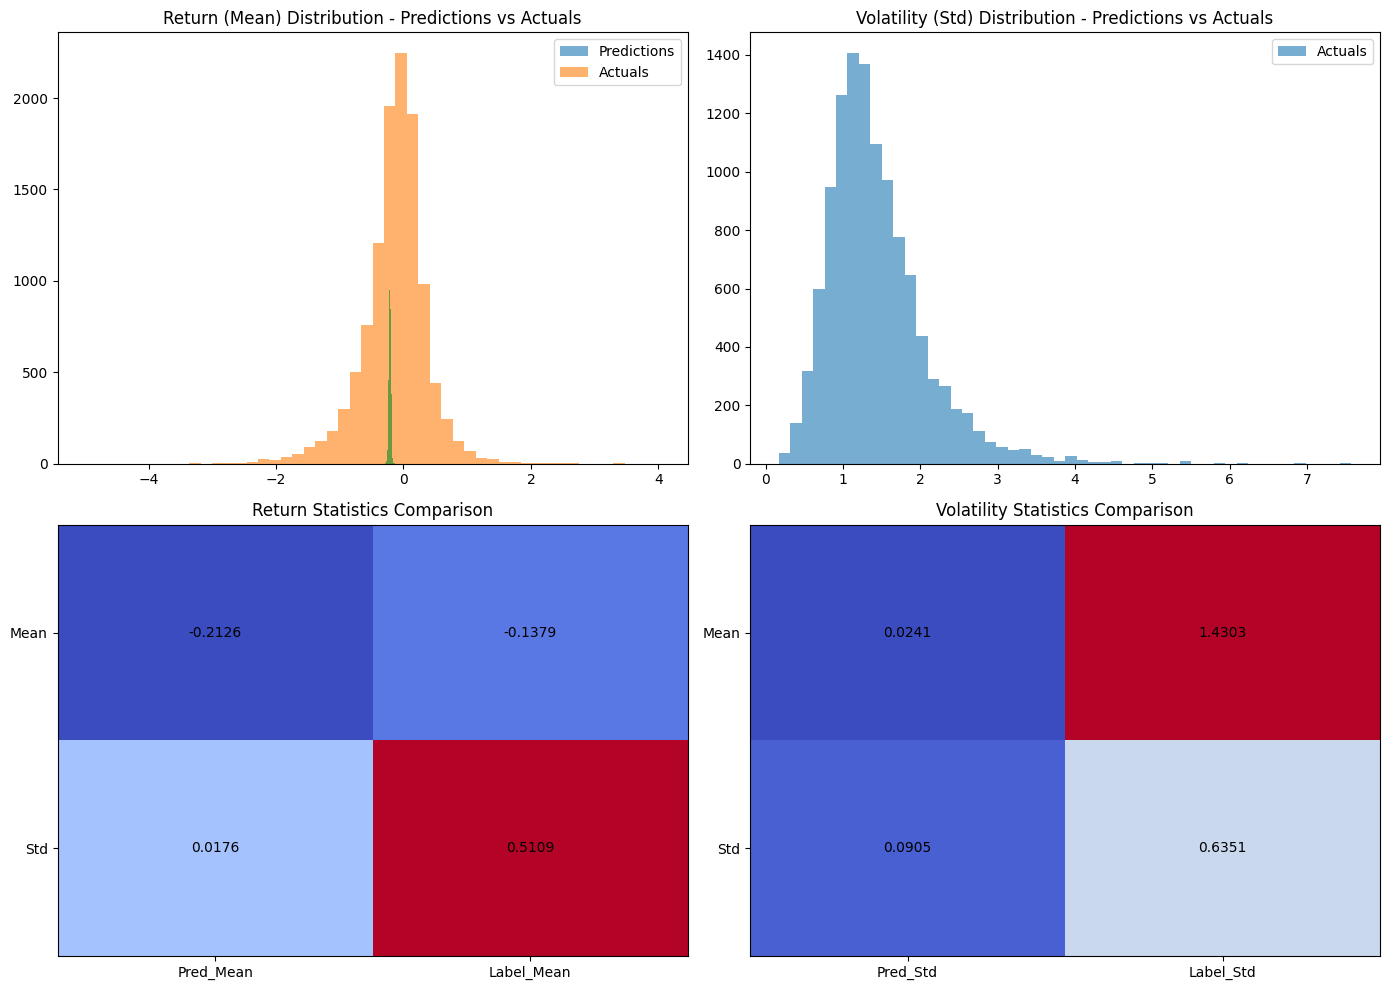

Correlation (Return):
Pearson r: 0.0801

Correlation (Volatility):
Pearson r: 0.1296


In [ ]:
# Add loss-curve analysis and robust plotting (handles torch tensors that require grad)
import matplotlib.pyplot as plt
import numpy as np
import torch
import pandas as pd

# Load the actual data (pred/label tensors) if available
pred_mean = torch.load(os.path.join(ROOT_FOLDER, "NGAT", "code", "pred_mean.pt"))
label_mean = torch.load(os.path.join(ROOT_FOLDER, "NGAT", "code", "label_mean.pt"))
pred_std = torch.load(os.path.join(ROOT_FOLDER, "NGAT", "code", "pred_std.pt"))
label_std = torch.load(os.path.join(ROOT_FOLDER, "NGAT", "code", "label_std.pt"))

# Helper to convert tensors (or arrays) to numpy safely
def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy() if x.requires_grad else x.cpu().numpy()
    elif isinstance(x, np.ndarray):
        return x
    else:
        try:
            return np.array(x)
        except Exception:
            return None

# Compare distributions (predicted vs actual)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten().reshape(2,2)

axes[0, 0].hist(to_numpy(pred_mean).flatten(), bins=50, alpha=0.6, label='Predictions')
axes[0, 0].hist(to_numpy(label_mean).flatten(), bins=50, alpha=0.6, label='Actuals')
axes[0, 0].set_title('Return (Mean) Distribution - Predictions vs Actuals')
axes[0, 0].legend()

axes[0, 1].hist(to_numpy(pred_std).flatten(), bins=50, alpha=0.6, label='Predictions')
axes[0, 1].hist(to_numpy(label_std).flatten(), bins=50, alpha=0.6, label='Actuals')
axes[0, 1].set_title('Volatility (Std) Distribution - Predictions vs Actuals')
axes[0, 1].legend()

# Statistics comparison for quick numeric check
stats_mean = pd.DataFrame({
    'Pred_Mean': [np.nanmean(to_numpy(pred_mean)), np.nanstd(to_numpy(pred_mean))],
    'Label_Mean': [np.nanmean(to_numpy(label_mean)), np.nanstd(to_numpy(label_mean))]
}, index=['Mean', 'Std'])
axes[1, 0].axis('off')
axes[1, 0].table(cellText=np.round(stats_mean.values,6), colLabels=stats_mean.columns, rowLabels=stats_mean.index, loc='center')
axes[1, 0].set_title('Return Statistics Comparison')

stats_std = pd.DataFrame({
    'Pred_Std': [np.nanmean(to_numpy(pred_std)), np.nanstd(to_numpy(pred_std))],
    'Label_Std': [np.nanmean(to_numpy(label_std)), np.nanstd(to_numpy(label_std))]
}, index=['Mean', 'Std'])
axes[1, 1].axis('off')
axes[1, 1].table(cellText=np.round(stats_std.values,6), colLabels=stats_std.columns, rowLabels=stats_std.index, loc='center')
axes[1, 1].set_title('Volatility Statistics Comparison')

plt.tight_layout()
plt.show()

# ------------------ Loss curve plotting ------------------
# Attempt to load saved train/val loss vectors from common locations
def try_load_losses():
    candidates = [
        os.path.join(ROOT_FOLDER, 'NGAT', 'code', 'train_loss.pt'),
        os.path.join(ROOT_FOLDER, 'NGAT', 'code', 'val_loss.pt'),
        os.path.join(ROOT_FOLDER, 'NGAT', 'code', 'loss_history.pt'),
        os.path.join(ROOT_FOLDER, 'NGAT', 'code', 'losses.npy'),
        os.path.join(ROOT_FOLDER, 'NGAT', 'code', 'history.npy'),
    ]
    out = {}
    for p in candidates:
        if os.path.exists(p):
            try:
                val = torch.load(p)
            except Exception:
                try:
                    val = np.load(p, allow_pickle=True)
                except Exception:
                    val = None
            out[os.path.basename(p)] = val
    return out

loss_files = try_load_losses()
train_loss = None
val_loss = None
# Heuristics: look for arrays named with 'train' and 'val' or 'history' dict
for name, data in loss_files.items():
    if data is None:
        continue
    if isinstance(data, dict):
        if 'train' in data:
            train_loss = data['train']
        if 'val' in data or 'validation' in data:
            val_loss = data.get('val') or data.get('validation')
    else:
        arr = to_numpy(data)
        if arr is None:
            continue
        # guess: if 1D and length>10, use as train or val depending on filename
        if 'train' in name.lower() and train_loss is None:
            train_loss = arr
        elif 'val' in name.lower() and val_loss is None:
            val_loss = arr
        elif train_loss is None:
            train_loss = arr
        elif val_loss is None:
            val_loss = arr

# If loading failed, try to find variables in current namespace (e.g., created during training run)
if train_loss is None and 'train_loss' in globals():
    train_loss = globals()['train_loss']
if val_loss is None and 'val_loss' in globals():
    val_loss = globals()['val_loss']

# Convert to numpy if needed
if isinstance(train_loss, torch.Tensor):
    train_loss = to_numpy(train_loss)
if isinstance(val_loss, torch.Tensor):
    val_loss = to_numpy(val_loss)

# Plot if available
if train_loss is not None and val_loss is not None:
    # ensure 1D numpy arrays
    train_loss = np.asarray(train_loss).ravel()
    val_loss = np.asarray(val_loss).ravel()
    epochs = np.arange(1, max(len(train_loss), len(val_loss)) + 1)

    # smoothing for visualization (rolling mean)
    def smooth(x, w=5):
        if len(x) < w:
            return x
        return pd.Series(x).rolling(w, min_periods=1, center=True).mean().values

    train_s = smooth(train_loss, w=5)
    val_s = smooth(val_loss, w=5)

    plt.figure(figsize=(10,5))
    plt.plot(np.arange(1, len(train_s)+1), train_s, label='Train (smoothed)')
    plt.plot(np.arange(1, len(val_s)+1), val_s, label='Validation (smoothed)')
    plt.scatter(np.argmin(val_s)+1, np.min(val_s), color='red', label=f'Min Val (epoch {np.argmin(val_s)+1})')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Learning Curves (smoothed)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Simple overfitting heuristic: if train keeps decreasing but val increases
    if len(train_s) >= 3 and len(val_s) >= 3:
        if train_s[-1] < train_s[0] and val_s[-1] > val_s[np.argmin(val_s)]:
            print('Warning: possible overfitting detected — validation loss rose after reaching min while training loss continued decreasing.')
        else:
            print('No clear overfitting pattern detected from loss curves.')
else:
    print('train_loss and val_loss not found in standard locations; please provide them as arrays named `train_loss` and `val_loss` or save them to NGAT/code/')
